# Computer Networks Project 2
## Network Automation Configuration Simulation using Python and NAPALM
William Miller, Marc Pham

## Introduction

“This project simulates NAPALM-based network automation using Python classes to represent network devices. This allows us to demonstrate configuration management, state retrieval, and reporting without requiring physical or virtual routers.”

## Motivation

Maybe add the capability of pinging other routers to see if all the IP addresses are configured correctly.

## Methodology

In [63]:
from napalm import get_network_driver
import time
import json
import os
from IPython.display import display, HTML, IFrame
import networkx as nx
import matplotlib.pyplot as plt
import ipaddress
from pyvis.network import Network
import dash
from dash import html
import dash_cytoscape as cyto
import numpy as np
from matplotlib.patches import Patch
from itertools import product

In [2]:
class driver:
    def __init__(self, hostname):
        self.hostname = hostname
        self.running_config = []
        self.candidate_config = []

        self.interfaces = {
            "eth0": {"is_up": True, "ip": None},
            "eth1": {"is_up": True, "ip": None},
        }

In [3]:
def load_merge_candidate(self, config):
    print(f"\n[{self.hostname}] load_merge_candidate()")
    self.candidate_config = config

driver.load_merge_candidate = load_merge_candidate

In [4]:
def compare_config(self):
    print(f"[{self.hostname}] compare_config()")

    diff = []

    for line in self.candidate_config:
        if line not in self.running_config:
            diff.append(f"+ {line}")

    for line in self.running_config:
        if line not in self.candidate_config:
            diff.append(f"- {line}")

    return "\n".join(diff)

driver.compare_config = compare_config

In [5]:
def commit_config(self):
    print(f"[{self.hostname}] commit_config()")

    self.running_config = self.candidate_config.copy()

    current_interface = None

    for line in self.candidate_config:
        parts = line.strip().split()

        if len(parts) == 0:
            continue

        if parts[0] == "interface":
            current_interface = parts[1]

            if current_interface not in self.interfaces:
                self.interfaces[current_interface] = {
                    "is_up": True,
                    "ip": None
                }

        elif len(parts) >= 3 and parts[0] == "ip" and parts[1] == "address":
            if current_interface:
                self.interfaces[current_interface]["ip"] = parts[2]

def discard_config(self):
    print(f"[{self.hostname}] discard_config()")
    self.candidate_config = []
    
driver.commit_config = commit_config
driver.discard_config = discard_config

In [6]:
def get_facts(self):
    return {
        "hostname": self.hostname,
        "vendor": "mock_napalm_driver",
        "config_lines": len(self.running_config),
    }

def get_interfaces(self):
    return self.interfaces

driver.get_facts = get_facts
driver.get_interfaces = get_interfaces

In [7]:
# ==============================
# CONFIG LOADER
# ==============================
def load_device_configs(filename):
    try:
        base_dir = os.path.dirname(os.path.abspath(__file__))
    except NameError:
        base_dir = os.getcwd()  # fallback for notebooks/interactive mode

    file_path = os.path.join(base_dir, filename)

    with open(file_path, "r") as f:
        return json.load(f)

def build_config(device_data):
    config = []

    config.append(f"hostname {device_data['hostname']}")

    for intf, ip in device_data["interfaces"].items():
        config.append(f"interface {intf}")
        if ip:
            config.append(f"ip address {ip}")

    return config    

In [8]:
def provision_devices(devices, config_file):
    configs = load_device_configs(config_file)

    print("\n===== PROVISIONING DEVICES =====")

    for name, data in configs.items():
        device = devices[name]

        config_lines = build_config(data)

        device.load_merge_candidate(config_lines)

        diff = device.compare_config()

        print(f"\n[{name}] CONFIG DIFF:")
        print(diff if diff else "No changes")

        if diff:
            device.commit_config()
        else:
            device.discard_config()

In [9]:
def generate_report(devices, output_file="network_report.json"):

    report = {}
    for name, device in devices.items():
        report[name] = {
            "facts": device.get_facts(),
            "interfaces": device.get_interfaces()
        }

    with open(output_file, "w") as f:
        json.dump(report, f, indent=4)

In [10]:
def build_network_graph(config_file, draw=True):
    try:
        base_dir = os.path.dirname(os.path.abspath(__file__))
    except NameError:
        base_dir = os.getcwd()

    file_path = os.path.join(base_dir, config_file)

    with open(file_path, "r") as f:
        configs = json.load(f)

    G = nx.Graph()
    subnet_map = {}

    # Step 1: Build subnet membership
    for device_name, data in configs.items():
        G.add_node(device_name, type="device")

        for intf, ip in data["interfaces"].items():
            if not ip:
                continue

            iface = ipaddress.ip_interface(ip)
            network = str(iface.network)

            subnet_map.setdefault(network, []).append(
                (device_name, intf, str(iface.ip))
            )

    # Step 2: Build graph
    for network, members in subnet_map.items():

        if len(members) == 1:
            # Create a "LAN node"
            device, intf, ip = members[0]

            lan_node = f"{network}"
            G.add_node(lan_node, type="network")

            G.add_edge(
                device,
                lan_node,
                interface=intf,
                ip=ip
            )

        else:
            # Normal device-to-device links
            for i in range(len(members)):
                for j in range(i + 1, len(members)):
                    d1, i1, ip1 = members[i]
                    d2, i2, ip2 = members[j]

                    G.add_edge(
                        d1,
                        d2,
                        network=network,
                        interfaces=f"{i1} ↔ {i2}",
                        ips=f"{ip1} ↔ {ip2}"
                    )

    # Step 3: Draw
    if draw:
        plt.figure(figsize=(12, 8), dpi=150)

        pos = nx.spring_layout(G, seed=42, k=2, iterations = 300)

        # Separate node types
        device_nodes = [n for n, d in G.nodes(data=True) if d["type"] == "device"]
        network_nodes = [n for n, d in G.nodes(data=True) if d["type"] == "network"]

        # Draw devices
        nx.draw_networkx_nodes(
            G, pos,
            nodelist=device_nodes,
            node_color="skyblue",
            node_size=1000,
            label="Devices"
        )

        # Draw networks (LANs)
        nx.draw_networkx_nodes(
            G, pos,
            nodelist=network_nodes,
            node_color="lightgreen",
            node_shape="s",
            node_size=1000,
            label="Networks"
        )

        # Draw edges
        nx.draw_networkx_edges(G, pos, edge_color="gray")

        # Labels
        nx.draw_networkx_labels(G, pos, font_size=7, font_weight="bold")

        # Edge labels (clean format: eth0: 10.0.0.1/30)
        edge_labels = {}
        
        for u, v, data in G.edges(data=True):
        
            key = tuple(sorted([u, v]))
        
            if "network" not in data:
                iface = data.get("interface", "")
                ip = data.get("ip", "")
                edge_labels[key] = f"{ip}"
        
            else:
                iface_pair = data.get("interfaces", "")
                ip_pair = data.get("ips", "")
        
                # split and label both sides cleanly
                if "↔" in iface_pair and "↔" in ip_pair:
                    i1, i2 = iface_pair.split("↔")
                    p1, p2 = ip_pair.split("↔")

                    edge_labels[(u, v)] = f"{u} ({p1.strip()}) ↔ {v} ({p2.strip()})"
                else:
                    edge_labels[(u, v)] = data.get("network", "")

        nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=9)

        plt.title("Network Topology", fontsize=16)
        plt.legend(
            loc='upper right',
            fontsize=14,
            markerscale=0.8,
            borderpad=1.5,
            labelspacing=1.2
        )
        plt.tight_layout(rect=[0, 0.05, 1, 1])
        plt.show()

    return G

In [11]:
def render_network_cytoscape(G):

    elements = []

    # -------------------------
    # NODES
    # -------------------------
    for node, data in G.nodes(data=True):

        if data.get("type") == "device":
            color = "skyblue"
            shape = "ellipse"
        else:
            color = "lightgreen"
            shape = "rectangle"

        elements.append({
            "data": {
                "id": node,
                "label": node
            },
            "style": {
                "background-color": color,
                "shape": shape
            }
        })

    # -------------------------
    # EDGES
    # -------------------------
    for u, v, data in G.edges(data=True):

        if "network" not in data:
            label = data.get("ip", "")
        else:
            iface_pair = data.get("interfaces", "")
            ip_pair = data.get("ips", "")

            if "↔" in iface_pair and "↔" in ip_pair:
                i1, i2 = iface_pair.split("↔")
                p1, p2 = ip_pair.split("↔")
                label = f"{u} ({p1.strip()}) ↔ {v} ({p2.strip()})"
            else:
                label = data.get("network", "")

        elements.append({
            "data": {
                "source": u,
                "target": v,
                "label": label
            }
        })

    # -------------------------
    # APP
    # -------------------------
    app = dash.Dash(__name__)

    app.layout = html.Div([
        cyto.Cytoscape(
            id="network",
            elements=elements,
            layout={
                "name": "cose",   # force-directed but stable
                "animate": False
            },
            style={"width": "100%", "height": "800px"},
            stylesheet=[
                {
                    "selector": "node",
                    "style": {
                        "label": "data(label)",
                        "font-size": "10px",
                        "text-valign": "center",
                        "text-halign": "center",
                        "color": "black"
                    }
                },
                {
                    "selector": "edge",
                    "style": {
                        "label": "data(label)",
                        "font-size": "8px",
                        "color": "black",
                
                        "text-background-color": "white",
                        "text-background-opacity": 1,
                        "text-background-padding": "3px",
                        "text-border-width": "0px",
                
                        "line-color": "#888",
                        "curve-style": "bezier"
                    }
                }
            ]
        )
    ])

    app.run(debug=False)

In [79]:
def plot_device_reachability_heatmap(G):

    device_nodes = [node for node, data in G.nodes(data=True) if data.get("type") == "device"]
    labels = [G.nodes[node].get("hostname", node) for node in device_nodes]
    n = len(device_nodes)
    
    matrix = np.zeros((n, n), dtype=int)
    for i, j in product(range(n), range(n)):
        if i == j: matrix[i][j] = 1
        else: matrix[i][j] = int(nx.has_path(G, device_nodes[i], device_nodes[j]))

    fig, ax = plt.subplots(figsize=(10, 8), dpi=150)
    im = ax.imshow(matrix, cmap="RdYlGn", vmin=0, vmax=1)

    ax.set(xticks=range(n), yticks=range(n), xticklabels=labels, yticklabels=labels,
           xlabel="Destination", ylabel="Source", title="Device-to-Device Connectivity"
    );

    ax.set_xticks(np.arange(-.5, n, 1), minor=True);
    ax.set_yticks(np.arange(-.5, n, 1), minor=True);
    ax.grid(which="minor", color="black", linewidth=0.5);
    ax.tick_params(which="minor", bottom=False, left=False);

    ax.legend(handles=[
        Patch(facecolor="green", label="Yes (Reachable)"),
        Patch(facecolor="red", label="No (Unreachable)")
    ], loc="lower right", bbox_to_anchor=(1.25, 1.0));

    plt.tight_layout();
    plt.show();
    

## Short Demonstration

This topology represents a simple hybrid network design with a core point-to-point backbone and two access networks. The link between R1 and R2 uses the 10.0.0.0/30 subnet, which is typically used for router-to-router connections because it provides exactly two usable IP addresses, one for each router interface. In addition to the backbone, each router connects to a separate /24 access network: R1 connects to the 192.168.1.0/24 subnet and R2 connects to the 192.168.2.0/24 subnet. These larger subnets represent local LAN segments or edge networks where end devices such as PCs or servers would reside. Overall, this design demonstrates a basic enterprise-style architecture with a structured separation between the core inter-router link and the access layer networks.


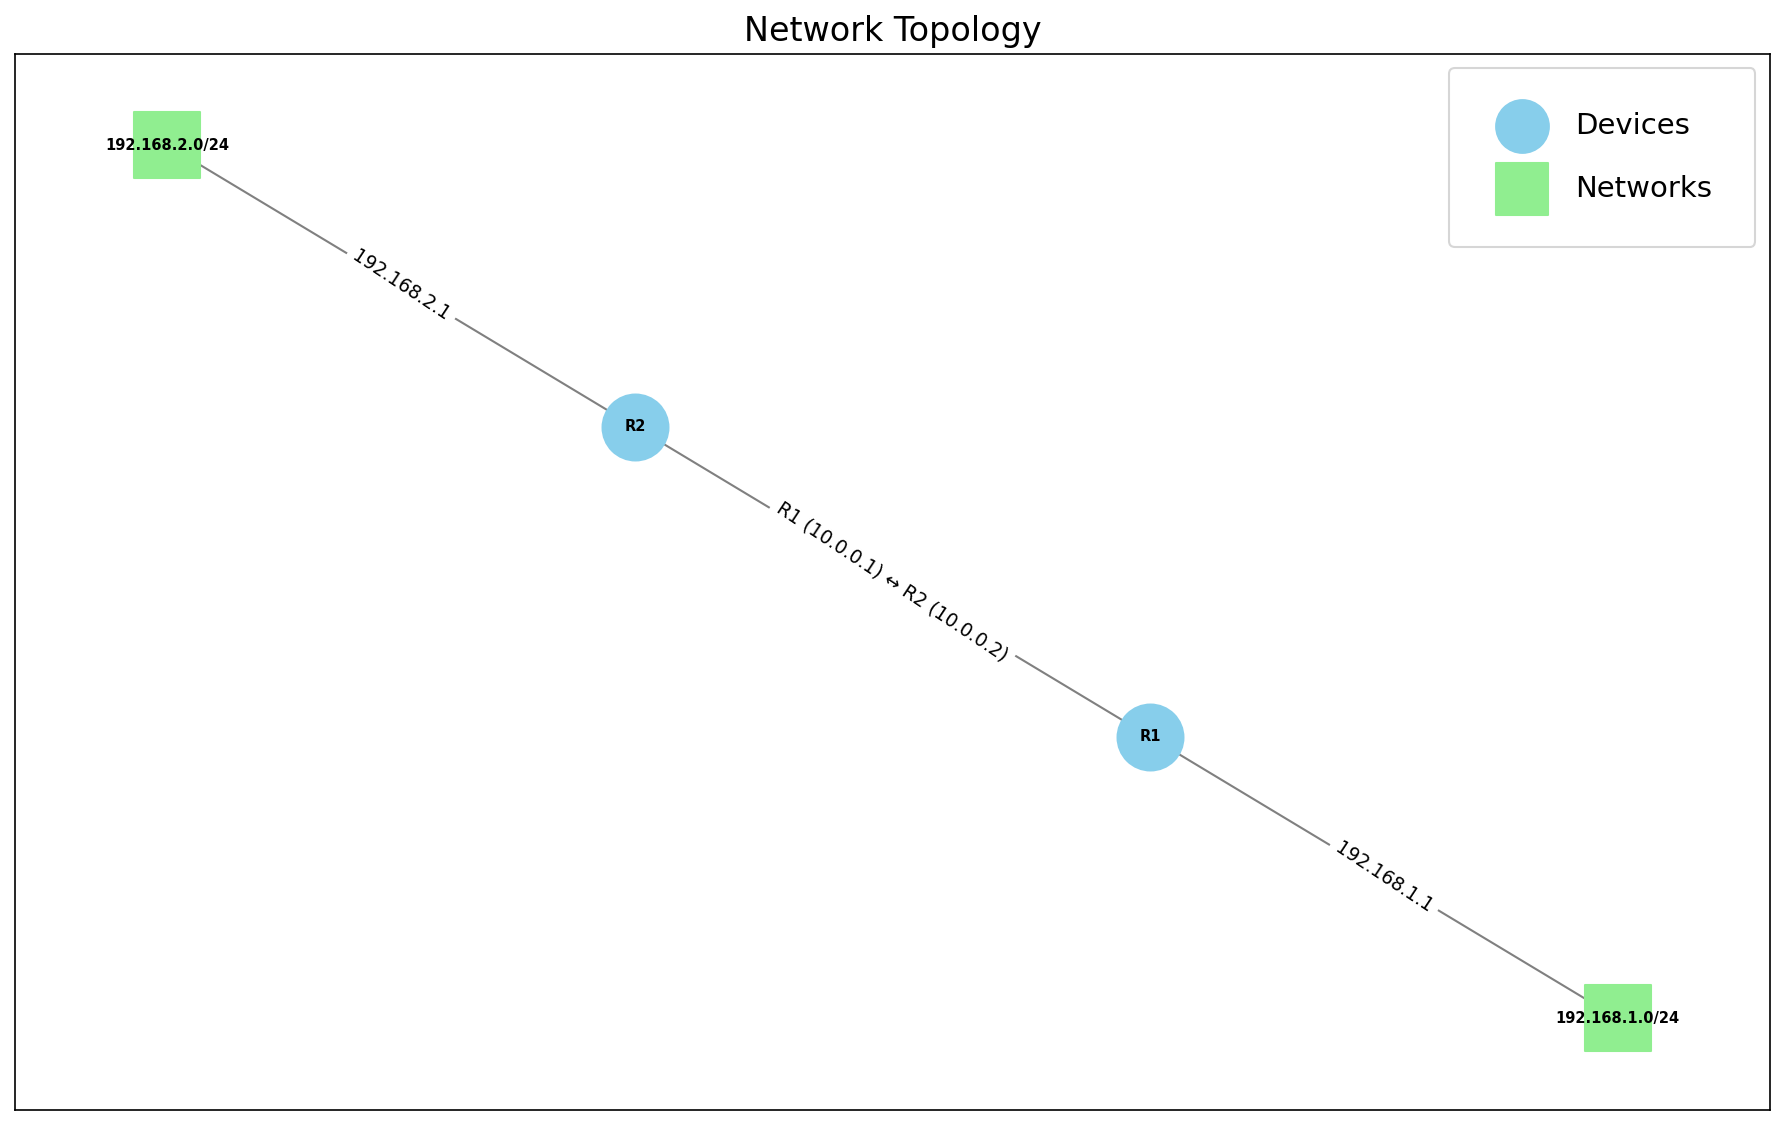


===== PROVISIONING DEVICES =====

[R1] load_merge_candidate()
[R1] compare_config()

[R1] CONFIG DIFF:
+ hostname R1
+ interface eth0
+ ip address 10.0.0.1/30
+ interface eth1
+ ip address 192.168.1.1/24
[R1] commit_config()

[R2] load_merge_candidate()
[R2] compare_config()

[R2] CONFIG DIFF:
+ hostname R2
+ interface eth0
+ ip address 10.0.0.2/30
+ interface eth1
+ ip address 192.168.2.1/24
[R2] commit_config()

===== NETWORK REPORT =====

--- R1 ---
FACTS:


{'hostname': 'R1', 'vendor': 'mock_napalm_driver', 'config_lines': 5}


INTERFACES:


{'eth0': {'is_up': True, 'ip': '10.0.0.1/30'},
 'eth1': {'is_up': True, 'ip': '192.168.1.1/24'}}


--- R2 ---
FACTS:


{'hostname': 'R2', 'vendor': 'mock_napalm_driver', 'config_lines': 5}


INTERFACES:


{'eth0': {'is_up': True, 'ip': '10.0.0.2/30'},
 'eth1': {'is_up': True, 'ip': '192.168.2.1/24'}}

In [80]:
G = build_network_graph("device_config1.json")

devices = {}
for node, data in G.nodes(data=True):
    if data.get("type") == "device":
        devices[node] = driver(hostname=node)

# Provision devices
provision_devices(devices, "device_config1.json")

print("\n===== NETWORK REPORT =====")

for name, device in devices.items():
    print(f"\n--- {name} ---")
    print("FACTS:")
    display(device.get_facts())

    print("\nINTERFACES:")
    display(device.get_interfaces())

# Generate report
generate_report(devices, "network_report1.json")

In [81]:
render_network_cytoscape(G)

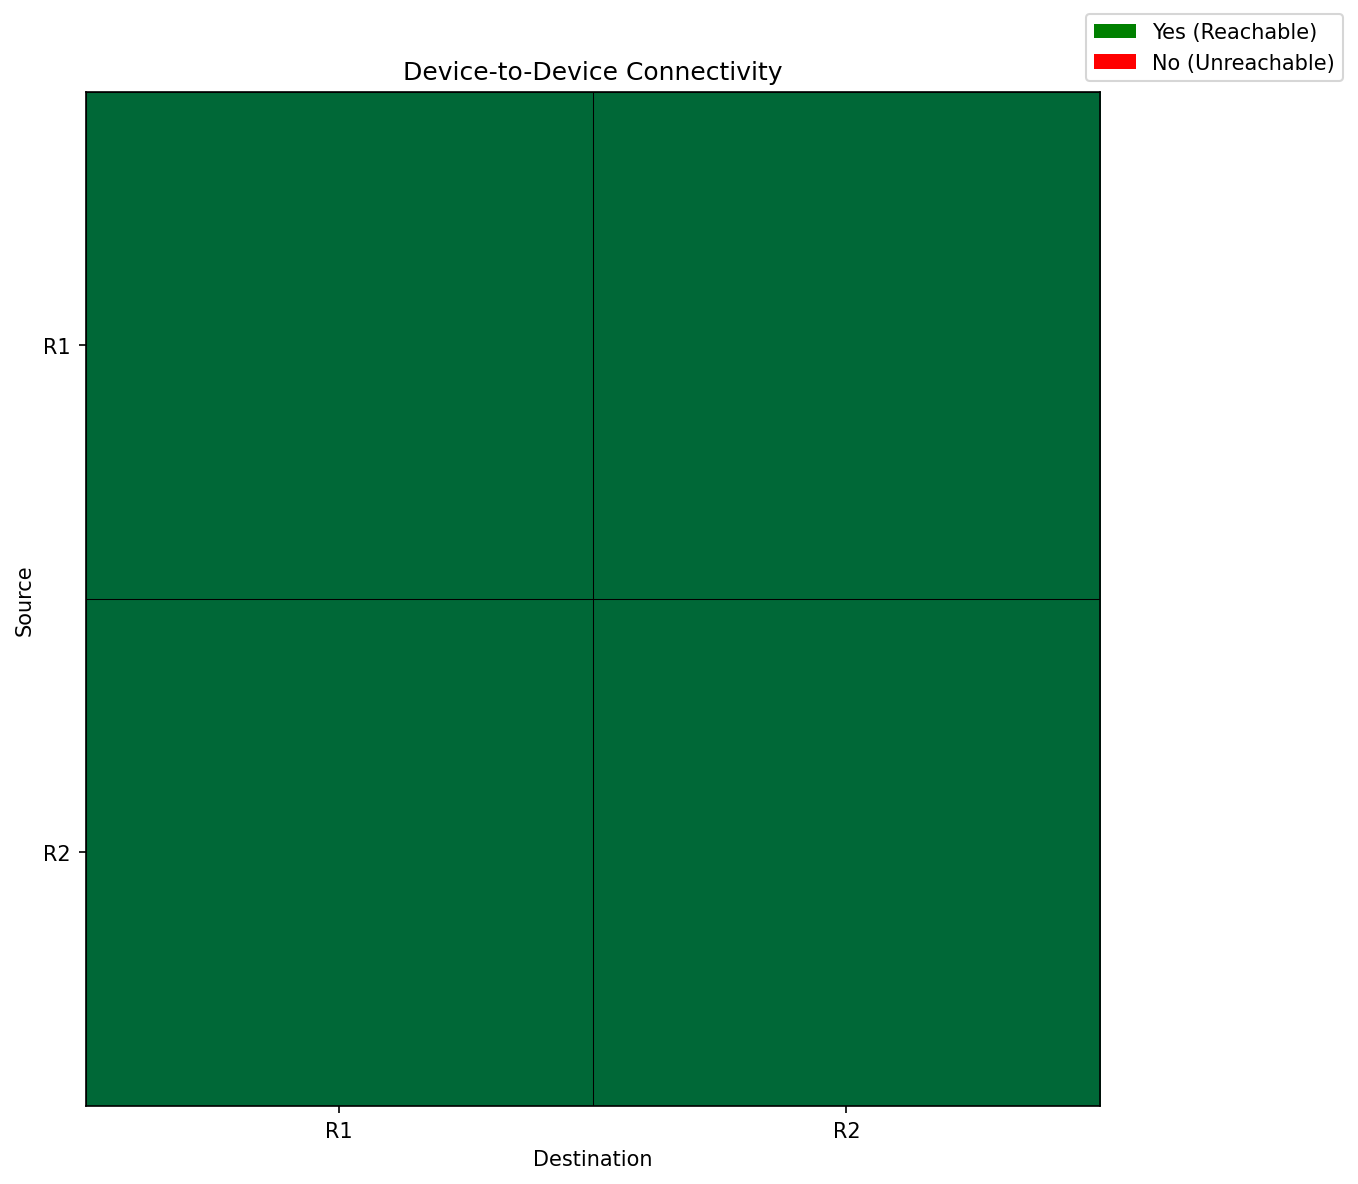

In [82]:
plot_device_reachability_heatmap(G)

The backbone network is divided into multiple /30 subnets, each representing a point-to-point link between two routers. Each /30 subnet provides four addresses: a network address, two usable IPs (assigned to the connected routers), and a broadcast address. For example, the...
- 10.0.0.0/30 subnet connects R1 and R2 using 10.0.0.1 and 10.0.0.2
- 10.0.0.4/30 subnet connectes R2 and R3 with usable addresses 10.0.0.5 and 10.0.0.6
- 10.0.0.8/30 subnet connects R3 and R4 with usable addresses 10.0.0.9 and 10.0.0.10
- 10.0.0.12/30 subnet connects R4 and R1 with usable addresses 10.0.0.13 and 10.0.0.14     

This design ensures that each router-to-router link is isolated in its own subnet, optimizing IP usage and reflecting standard practices for point-to-point backbone connections. For the access / edge layer, let's assign the IP addresses, like so:
* 192.168.1.0/24 subnet connects R1 and R5 using 192.168.1.1 and 192.168.1.2
* 192.168.2.0/24 subnet connects R1 and R6 using 192.168.2.1 and 192.168.2.2
* 192.168.3.0/24 subnet connects R2 and R7 using 192.168.3.1 and 192.168.3.2
* 192.168.4.0/24 subnet connects R2 and R8 using 192.168.4.1 and 192.168.4.2
* 192.168.5.0/24 subnet connects R3 and R9 using 192.168.5.1 and 192.168.5.2
* 192.168.6.0/24 subnet connects R3 and R10 using 192.168.6.1 and 192.168.6.2
* 192.168.7.0/24 subnet connects R4 and R11 using 192.168.7.1 and 192.168.7.2
* 192.168.8.0/24 subnet connects R4 and R12 using 192.168.8.1 and 192.168.8.2


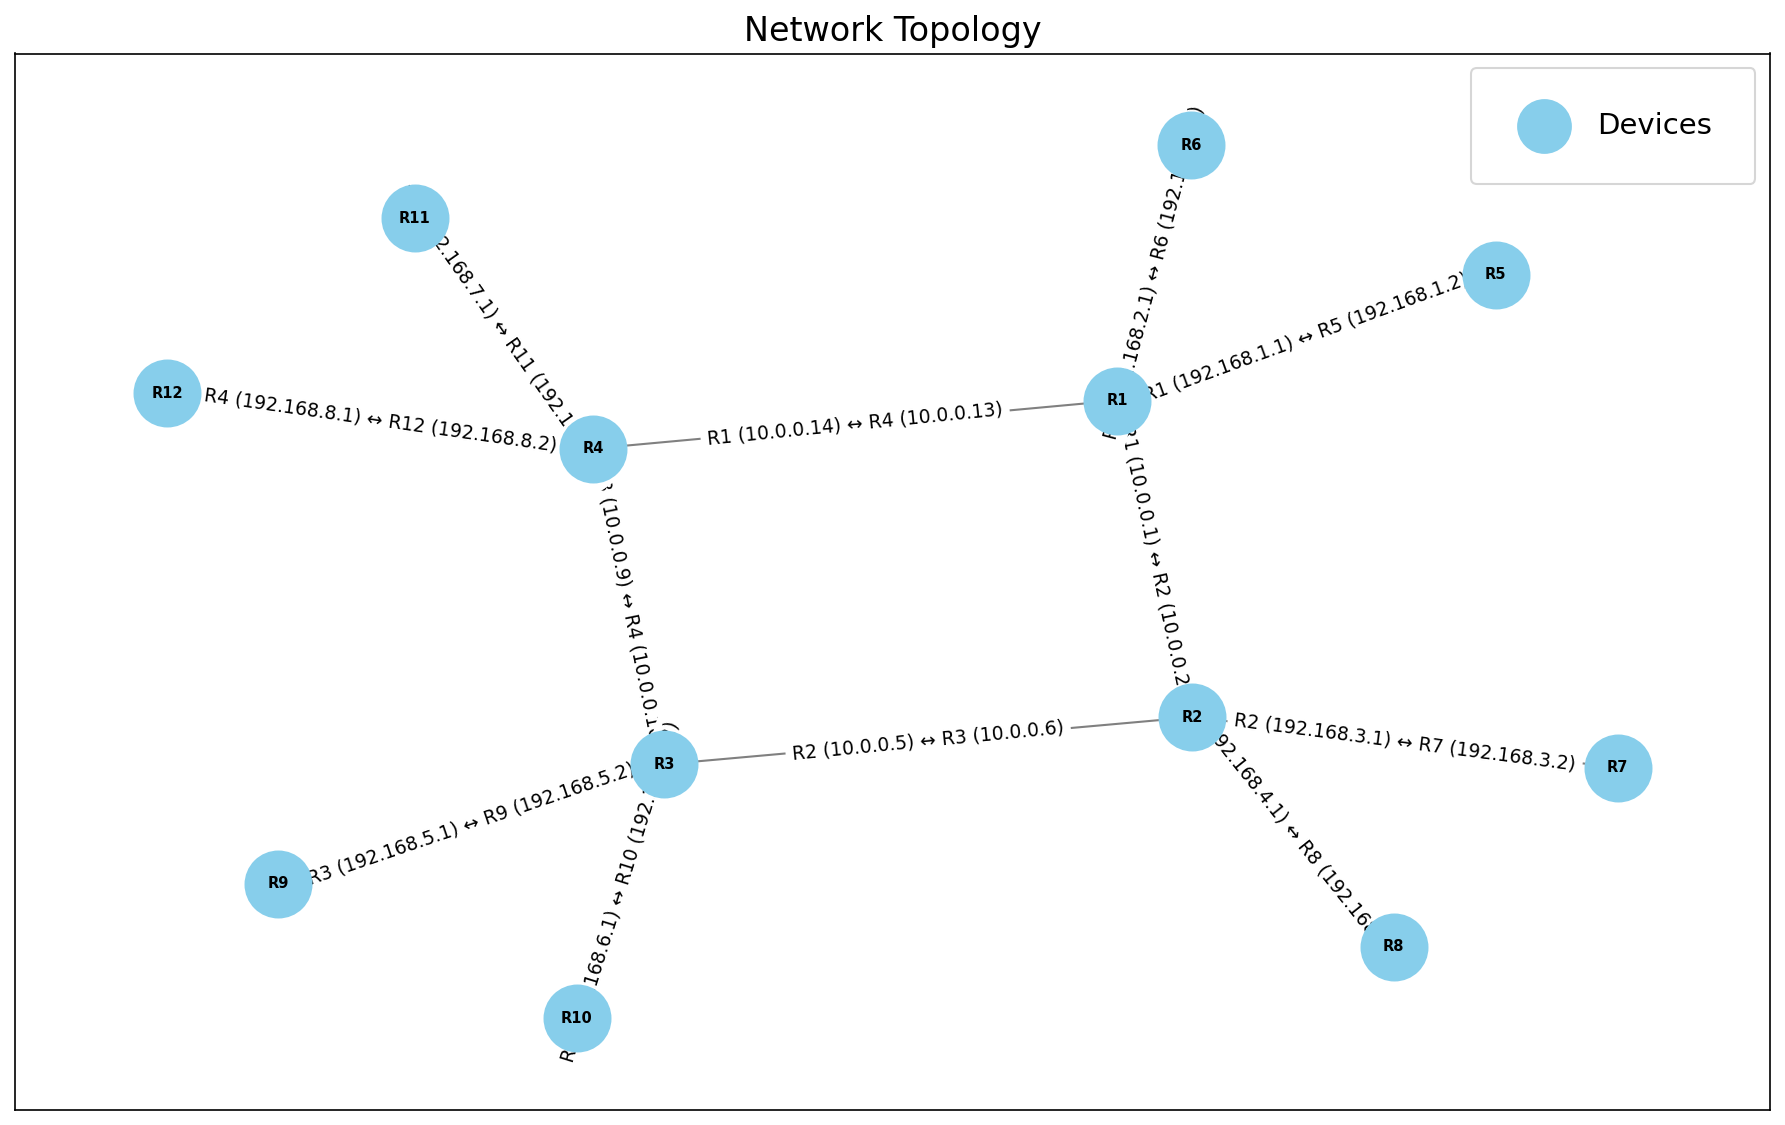


===== PROVISIONING DEVICES =====

[R1] load_merge_candidate()
[R1] compare_config()

[R1] CONFIG DIFF:
+ hostname R1-Core
+ interface eth0
+ ip address 10.0.0.1/30
+ interface eth1
+ ip address 10.0.0.14/30
+ interface eth2
+ ip address 192.168.1.1/24
+ interface eth3
+ ip address 192.168.2.1/24
[R1] commit_config()

[R2] load_merge_candidate()
[R2] compare_config()

[R2] CONFIG DIFF:
+ hostname R2-Core
+ interface eth0
+ ip address 10.0.0.2/30
+ interface eth1
+ ip address 10.0.0.5/30
+ interface eth2
+ ip address 192.168.3.1/24
+ interface eth3
+ ip address 192.168.4.1/24
[R2] commit_config()

[R3] load_merge_candidate()
[R3] compare_config()

[R3] CONFIG DIFF:
+ hostname R3-Core
+ interface eth0
+ ip address 10.0.0.6/30
+ interface eth1
+ ip address 10.0.0.9/30
+ interface eth2
+ ip address 192.168.5.1/24
+ interface eth3
+ ip address 192.168.6.1/24
[R3] commit_config()

[R4] load_merge_candidate()
[R4] compare_config()

[R4] CONFIG DIFF:
+ hostname R4-Core
+ interface eth0
+ ip ad

{'hostname': 'R1', 'vendor': 'mock_napalm_driver', 'config_lines': 9}


INTERFACES:


{'eth0': {'is_up': True, 'ip': '10.0.0.1/30'},
 'eth1': {'is_up': True, 'ip': '10.0.0.14/30'},
 'eth2': {'is_up': True, 'ip': '192.168.1.1/24'},
 'eth3': {'is_up': True, 'ip': '192.168.2.1/24'}}


--- R2 ---
FACTS:


...

{'eth0': {'is_up': True, 'ip': '192.168.7.2/24'},
 'eth1': {'is_up': True, 'ip': None}}


--- R12 ---
FACTS:


{'hostname': 'R12', 'vendor': 'mock_napalm_driver', 'config_lines': 3}


INTERFACES:


{'eth0': {'is_up': True, 'ip': '192.168.8.2/24'},
 'eth1': {'is_up': True, 'ip': None}}

In [85]:
G = build_network_graph("device_config2.json")

devices = {}
for node, data in G.nodes(data=True):
    if data.get("type") == "device":
        devices[node] = driver(hostname=node)

# Provision devices
provision_devices(devices, "device_config2.json")
generate_report(devices)

# Show live device state (important for demo proof)
print("LIVE DEVICE STATE CHECK")

for name, device in devices.items():
    print(f"\n--- {name} ---")
    print("FACTS:")
    display(device.get_facts())

    print("\nINTERFACES:")
    display(device.get_interfaces())

# Generate report
generate_report(devices, "network_report2.json")

In [87]:
render_network_cytoscape(G)

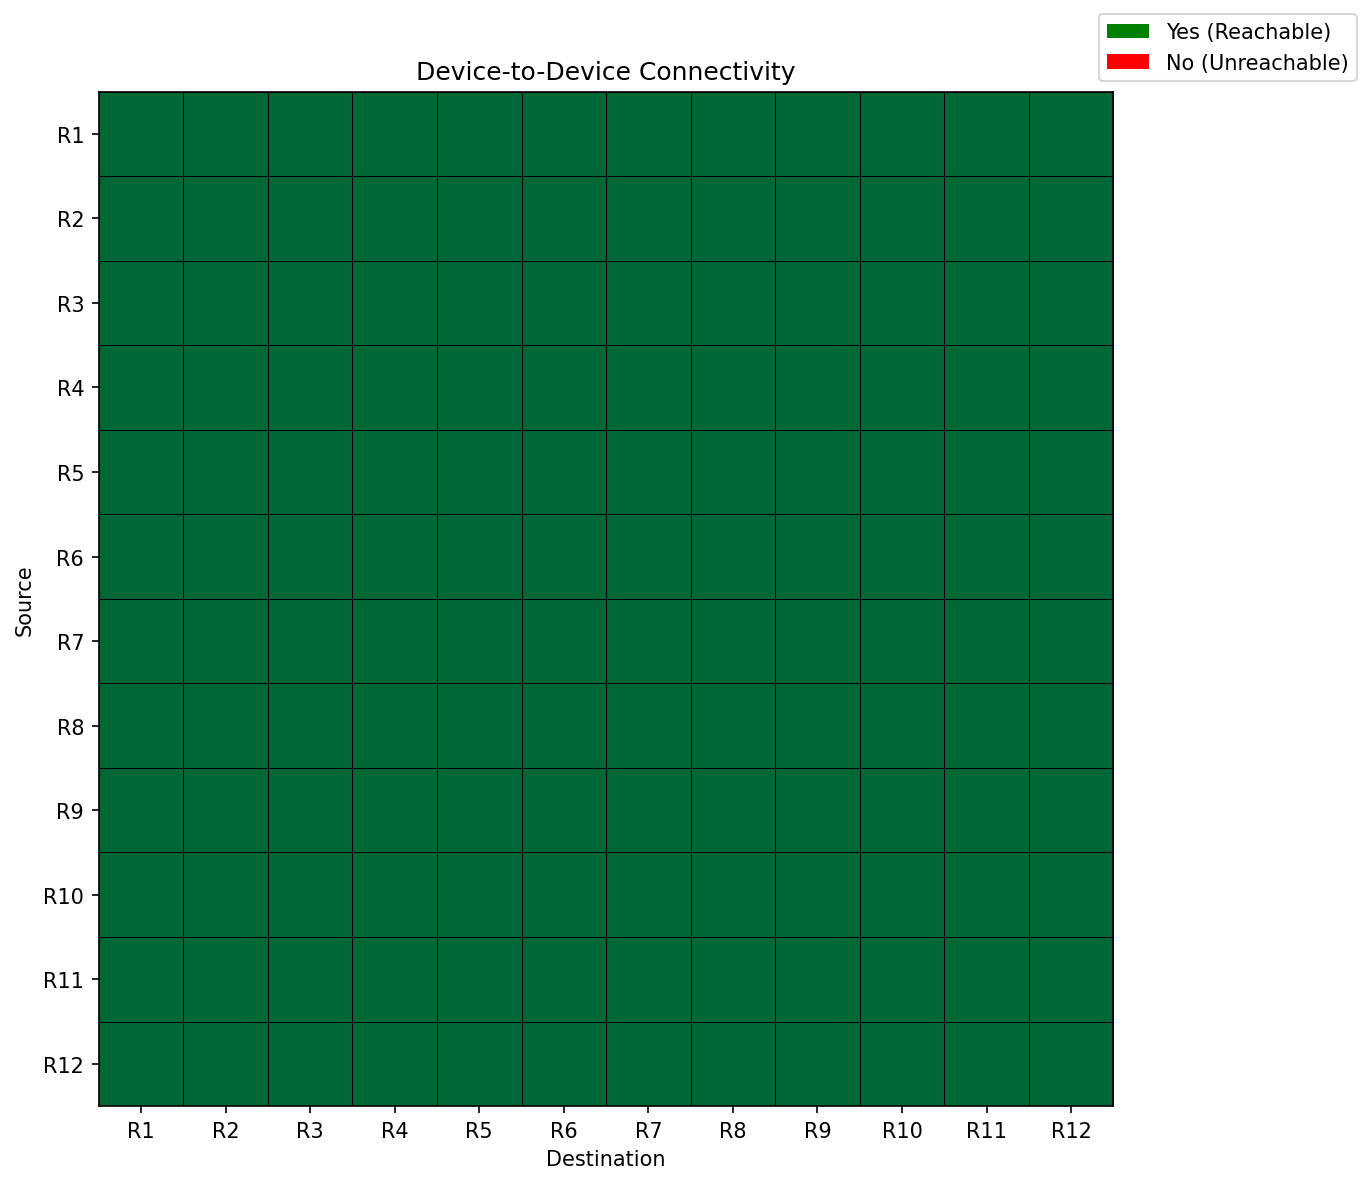

In [88]:
plot_device_reachability_heatmap(G)

## Summary and Conclusion

## Distribution of Work